In [2]:
import pathlib
from os import path, getcwd, chdir

import numpy as np
from tqdm import tqdm

chdir(r'C:\Users\IanFu\Desktop\~1_CURRENT\efsprapy\01-analysis\sensitivity_sprinkler_type')


def read_data(parent_dir: pathlib.Path) -> (list, list):
    folders = [item for item in parent_dir.iterdir() if item.is_dir()]
    folders.sort()
    processed_data = dict()
    for folder in tqdm(folders):
        case_name = folder.name.split('-')[0]
        separation_distance = float(folder.name.split('-')[-1])
        fp_output = folder / f'{folder.name}_out.csv'
        try:
            assert path.exists(fp_output), f'file does not exist {fp_output}'
        except AssertionError:
            continue
        mcs_output = np.genfromtxt(fp_output, delimiter=",", skip_header=1)

        N = np.shape(mcs_output)[0]

        # find all iterations that ignition occurred
        t_ig_ftp = mcs_output[:, 2]
        P_ig = sum(np.logical_and(t_ig_ftp > 0, t_ig_ftp < np.inf)) / N

        if case_name not in processed_data:
            processed_data[case_name] = dict(sep=list(), pig=list(), )

        processed_data[case_name]['sep'].append(separation_distance)
        processed_data[case_name]['pig'].append(P_ig)
    return processed_data


data = dict(
    occ_type=read_data(pathlib.Path(getcwd(), 'sprinkler_type')),
)

100%|██████████| 36/36 [00:00<00:00, 462.63it/s]


C:\Users\IanFu_uum5m5b\AppData\Local\Temp\ipykernel_31040\2622213686.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


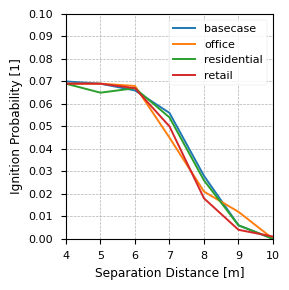

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, ax = plt.subplots(figsize=(3, 3), dpi=100)

lines = dict()
# for occ_type, data_ in data['occ_type'].items():
for occ_type, data_ in data['occ_type'].items():
    lines[occ_type] = ax.plot(*zip(*sorted(zip(data['occ_type'][occ_type]['sep'], data['occ_type'][occ_type]['pig']))),
                              label=occ_type.title())
ax.set_xlabel("Separation Distance [m]")
ax.set_ylabel("Ignition Probability [1]")
ax.set_xlim(4, 10)
ax.set_yticks(np.arange(0, 1.1, 0.01))
ax.set_ylim(0, .1)
ax.grid(which="both", ls="--", lw=0.5)

# br 187 084 base case
# lines = dict()
# for label, data_ in data.items():
#     lines[label] = ax.plot(*data_, label=label)

ax.legend(loc='upper right')

fig.tight_layout()
fig.show()